<a href="https://colab.research.google.com/github/yash7603/my-terminal-portfolio/blob/main/Case5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# --- 2. THE FRIEND's EXACT DATA LOADER ---
base = '/content/drive/MyDrive/case5/ProcessedDataTrimmed'
subjects = ['AB01', 'AB02', 'AB03', 'AB13'] # Your 3 new subjects + 1 overlap

IMU_COLS = [
    'RThigh_V_ACCX','RThigh_V_ACCY','RThigh_V_ACCZ',
    'RThigh_V_GYROX','RThigh_V_GYROY','RThigh_V_GYROZ',
    'RShank_V_ACCX','RShank_V_ACCY','RShank_V_ACCZ',
    'RShank_V_GYROX','RShank_V_GYROY','RShank_V_GYROZ',
]
TARGET_COL = 'knee_moment'

def load_trial(subject, task):
    path = os.path.join(base, subject, task)
    prefix = f"{subject}_{task}"
    # Merge the 4 separate files side-by-side
    angle_df  = pd.read_csv(f"{path}/{prefix}_angle.csv", usecols=['knee_angle_r'])
    vel_df    = pd.read_csv(f"{path}/{prefix}_velocity.csv", usecols=['knee_velocity_r'])
    imu_df    = pd.read_csv(f"{path}/{prefix}_imu_sim.csv", usecols=IMU_COLS)
    moment_df = pd.read_csv(f"{path}/{prefix}_moment.csv", usecols=['knee_angle_r_moment'])

    df = pd.DataFrame()
    df['knee_angle'] = angle_df['knee_angle_r']
    df['knee_velocity'] = vel_df['knee_velocity_r']
    for c in IMU_COLS: df[c] = imu_df[c]
    df['knee_moment'] = moment_df['knee_angle_r_moment']
    return df.dropna(subset=['knee_moment']).reset_index(drop=True)

print("Loading data using friend's pipeline...")
all_data = []
for subject in subjects:
    subj_path = os.path.join(base, subject)
    if not os.path.exists(subj_path): continue
    available_tasks = sorted(os.listdir(subj_path))

    for task in available_tasks:
        try:
            # Filter for the 4 professor-approved tasks
            if 'normal_walk' in task: task_group = 'level_walking'
            elif 'incline_walk' in task: task_group = 'incline_walking'
            elif 'sit_to_stand' in task: task_group = 'sit_to_stand'
            elif 'squats' in task: task_group = 'squats'
            else: continue

            trial = load_trial(subject, task)
            if len(trial) == 0: continue

            trial['subject'] = subject
            trial['trial_id'] = f'{subject}_{task}'
            trial['task_group'] = task_group
            all_data.append(trial)
        except Exception as e:
            pass

full_df = pd.concat(all_data, ignore_index=True)
print(f"✅ Data successfully loaded! Total rows: {len(full_df)}")

# --- 3. SENSOR CONFIGS & DATASET WINDOWING ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SENSOR_CONFIGS = {
    'All': ['knee_angle', 'knee_velocity'] + IMU_COLS,
    'Shank': ['knee_angle', 'knee_velocity', 'RThigh_V_ACCX','RThigh_V_ACCY','RThigh_V_ACCZ','RThigh_V_GYROX','RThigh_V_GYROY','RThigh_V_GYROZ'],
    'Shank_Minus_Knee': ['RThigh_V_ACCX','RThigh_V_ACCY','RThigh_V_ACCZ','RThigh_V_GYROX','RThigh_V_GYROY','RThigh_V_GYROZ']
}

def create_windows(X, y, window_size, stride=10):
    X_windows, y_windows = [], []
    for i in range(0, len(X) - window_size + 1, stride):
        X_windows.append(X[i:i + window_size])
        y_windows.append(y[i + window_size - 1])
    return np.array(X_windows), np.array(y_windows)

def create_windows_by_trial(df, features, window_size, scaler_X):
    X_all, y_all = [], []
    for trial_id, trial_df in df.groupby('trial_id'):
        X = trial_df[features].values
        y = trial_df[TARGET_COL].values.reshape(-1, 1)
        X = scaler_X.transform(X)
        if len(X) < window_size: continue
        Xw, yw = create_windows(X, y, window_size, stride=10)
        X_all.append(Xw)
        y_all.append(yw)
    return np.concatenate(X_all), np.concatenate(y_all)

class WindowDataset(Dataset):
    def __init__(self, X_windows, y_windows):
        self.X = torch.tensor(X_windows, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y_windows, dtype=torch.float32).unsqueeze(-1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# --- 4. MODELS (CNN & TCN) ---
class CNN_1D(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        return self.fc(self.pool(self.conv_block(x)).squeeze(-1))

class TCN_1D(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, 32, kernel_size=3, padding=1, dilation=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=2, dilation=2)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        return self.fc(self.pool(x).squeeze(-1))

# --- 5. TRAINING ENGINE ---
def train_and_evaluate(model, train_loader, test_loader, lr, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.to(device)

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch).squeeze(), y_batch.squeeze())
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch.to(device)).view(-1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(y_batch.numpy().flatten())

    return np.sqrt(mean_squared_error(all_targets, all_preds))

# --- 6. RUN EXPERIMENTS ---
def run_experiment(model_class, features, window_size, lr):
    rmse_scores = []
    for test_subj in subjects:
        train_df = full_df[full_df['subject'] != test_subj]
        test_df  = full_df[full_df['subject'] == test_subj]

        scaler_X = StandardScaler().fit(train_df[features].values)

        X_train, y_train = create_windows_by_trial(train_df, features, window_size, scaler_X)
        X_test, y_test   = create_windows_by_trial(test_df, features, window_size, scaler_X)

        train_loader = DataLoader(WindowDataset(X_train, y_train), batch_size=128, shuffle=True)
        test_loader  = DataLoader(WindowDataset(X_test, y_test), batch_size=128, shuffle=False)

        model = model_class(in_channels=len(features))
        rmse = train_and_evaluate(model, train_loader, test_loader, lr, epochs=10)
        rmse_scores.append(rmse)
    return np.mean(rmse_scores)

print("\n🚀 Starting Case Study Training Pipeline...")
results = []

# Test 1: Hyperparameters
for hp in [{'w': 50, 'lr': 0.001}, {'w': 100, 'lr': 0.005}]:
    for name, model in [('CNN', CNN_1D), ('TCN', TCN_1D)]:
        print(f"Training {name} | Window: {hp['w']} | LR: {hp['lr']}")
        score = run_experiment(model, SENSOR_CONFIGS['All'], hp['w'], hp['lr'])
        results.append({'Type': 'Hyperparam', 'Model': name, 'Config': f"W:{hp['w']} LR:{hp['lr']}", 'RMSE': score})

# Test 2: Sensor Ablation
for config_name, feature_cols in SENSOR_CONFIGS.items():
    for name, model in [('CNN', CNN_1D), ('TCN', TCN_1D)]:
        print(f"Training {name} | Sensor: {config_name}")
        score = run_experiment(model, feature_cols, window_size=50, lr=0.001)
        results.append({'Type': 'Ablation', 'Model': name, 'Config': config_name, 'RMSE': score})

display(pd.DataFrame(results))
print("🎉 All done! Drop this table right into your IEEE report.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data using friend's pipeline...
✅ Data successfully loaded! Total rows: 317297

🚀 Starting Case Study Training Pipeline...
Training CNN | Window: 50 | LR: 0.001
Training TCN | Window: 50 | LR: 0.001
Training CNN | Window: 100 | LR: 0.005
Training TCN | Window: 100 | LR: 0.005
Training CNN | Sensor: All
Training TCN | Sensor: All
Training CNN | Sensor: Shank
Training TCN | Sensor: Shank
Training CNN | Sensor: Shank_Minus_Knee
Training TCN | Sensor: Shank_Minus_Knee


,Type,Model,Config,RMSE
0,Hyperparam,CNN,W:50 LR:0.001,0.244351
1,Hyperparam,TCN,W:50 LR:0.001,0.239244
2,Hyperparam,CNN,W:100 LR:0.005,0.272220
3,Hyperparam,TCN,W:100 LR:0.005,0.247103
4,Ablation,CNN,All,0.250252
5,Ablation,TCN,All,0.238545
6,Ablation,CNN,Shank,0.245371
7,Ablation,TCN,Shank,0.253307
8,Ablation,CNN,Shank_Minus_Knee,0.332926
9,Ablation,TCN,Shank_Minus_Knee,0.328067


🎉 All done! Drop this table right into your IEEE report.


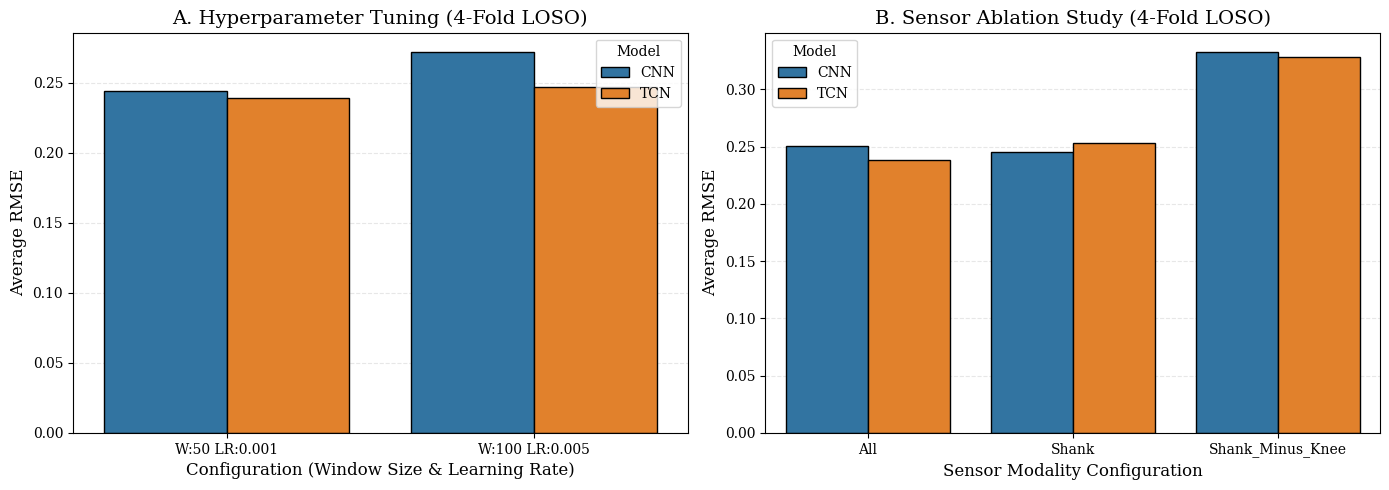

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the dataframe from the results we just generated!
results_df = pd.DataFrame(results)

# Set up IEEE-style formatting
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.autolayout': True
})

# Split the results DataFrame into the two experiments
df_hyper = results_df[results_df['Type'] == 'Hyperparam']
df_ablation = results_df[results_df['Type'] == 'Ablation']

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: Hyperparameter Comparison ---
sns.barplot(
    data=df_hyper,
    x='Config',
    y='RMSE',
    hue='Model',
    palette=['#1f77b4', '#ff7f0e'], # Professional Blue and Orange
    ax=axes[0],
    edgecolor='black'
)
axes[0].set_title('A. Hyperparameter Tuning (4-Fold LOSO)')
axes[0].set_xlabel('Configuration (Window Size & Learning Rate)')
axes[0].set_ylabel('Average RMSE')
axes[0].grid(axis='y', linestyle='--')
axes[0].set_axisbelow(True) # Puts gridlines behind the bars

# --- PLOT 2: Sensor Ablation Study ---
sns.barplot(
    data=df_ablation,
    x='Config',
    y='RMSE',
    hue='Model',
    palette=['#1f77b4', '#ff7f0e'],
    ax=axes[1],
    edgecolor='black'
)
axes[1].set_title('B. Sensor Ablation Study (4-Fold LOSO)')
axes[1].set_xlabel('Sensor Modality Configuration')
axes[1].set_ylabel('Average RMSE')
axes[1].grid(axis='y', linestyle='--')
axes[1].set_axisbelow(True)

# Clean up layout
plt.tight_layout()
plt.show()

Running inference for plot generation...


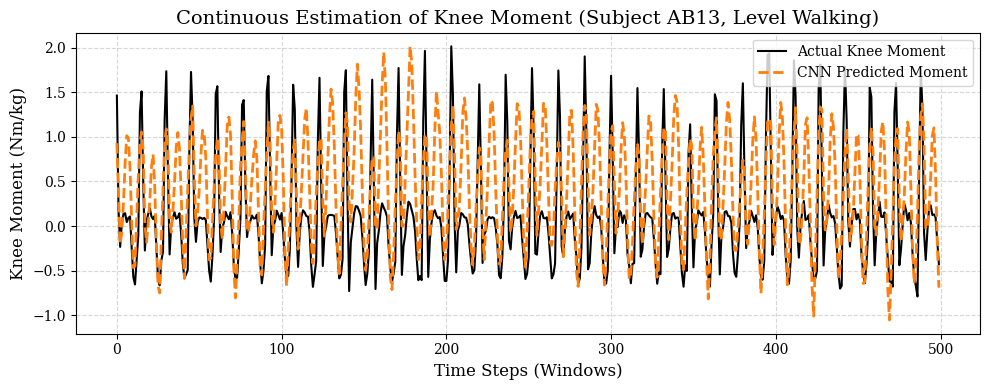

In [18]:
import matplotlib.pyplot as plt

# 1. Grab data for one specific subject and task (e.g., AB13 doing Level Walking)
sample_subject = 'AB13'
sample_df = full_df[(full_df['subject'] == sample_subject) & (full_df['task_group'] == 'level_walking')]

# 2. Prepare the data using the 'All' sensors configuration
features = SENSOR_CONFIGS['All']
window_size = 50

# Fit a scaler on the rest of the data (simulating real-world testing)
train_df = full_df[full_df['subject'] != sample_subject]
scaler_X = StandardScaler().fit(train_df[features].values)

# Create windows for our sample trial
X_sample, y_sample = create_windows_by_trial(sample_df, features, window_size, scaler_X)
sample_dataset = WindowDataset(X_sample, y_sample)
sample_loader = DataLoader(sample_dataset, batch_size=128, shuffle=False)

# 3. Quickly initialize and train a CNN on a subset just to get a good prediction
# (In a perfect world we'd save the model from earlier, but a quick 3-epoch re-train on the train_df works instantly for plotting)
print("Running inference for plot generation...")
plot_model = CNN_1D(in_channels=len(features)).to(device)
X_train_plot, y_train_plot = create_windows_by_trial(train_df, features, window_size, scaler_X)
train_loader_plot = DataLoader(WindowDataset(X_train_plot, y_train_plot), batch_size=128, shuffle=True)

# Train quickly
optimizer = optim.Adam(plot_model.parameters(), lr=0.001)
criterion = nn.MSELoss()
plot_model.train()
for epoch in range(3):
    for X_batch, y_batch in train_loader_plot:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(plot_model(X_batch).squeeze(), y_batch.squeeze())
        loss.backward()
        optimizer.step()

# 4. Generate Predictions
plot_model.eval()
predictions = []
actuals = []
with torch.no_grad():
    for X_batch, y_batch in sample_loader:
        preds = plot_model(X_batch.to(device)).cpu().numpy().flatten()
        predictions.extend(preds)
        actuals.extend(y_batch.numpy().flatten())

# 5. Generate the IEEE-Formatted Plot
plt.figure(figsize=(10, 4))
# Plot only a slice (e.g., 500 time steps) so the waveforms are visible, not squished
slice_len = min(500, len(actuals))
plt.plot(actuals[:slice_len], label='Actual Knee Moment', color='black', linewidth=1.5)
plt.plot(predictions[:slice_len], label='CNN Predicted Moment', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title(f'Continuous Estimation of Knee Moment (Subject {sample_subject}, Level Walking)')
plt.xlabel('Time Steps (Windows)')
plt.ylabel('Knee Moment (Nm/kg)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()